Caracterización del tráfico


In [ ]:
variables_trafico = ['granel_solido_t','granel_liquido_t','mercancia_general_t',
                     'contenedores_teu','escalas_buque']

def sensibilidad(d):
    return pd.DataFrame({
        'Indicador': variables_trafico,
        'Corr. número episodios':[d[v].corr(d['numero_episodios']) for v in variables_trafico],
        'Corr. horas episodios':[d[v].corr(d['horas_episodios']) for v in variables_trafico]
    }).round(3)

print('Bilbao')
print(sensibilidad(bilbao_final).to_string(index=False))
print()
print('Gijón')
print(sensibilidad(gijon_final).to_string(index=False))

Bilbao
          Indicador  Corr. número episodios  Corr. horas episodios
    granel_solido_t                   0.298                  0.271
   granel_liquido_t                   0.068                  0.058
mercancia_general_t                   0.096                 -0.015
   contenedores_teu                  -0.004                 -0.061
      escalas_buque                   0.015                 -0.049

Gijón
          Indicador  Corr. número episodios  Corr. horas episodios
    granel_solido_t                   0.367                  0.321
   granel_liquido_t                   0.087                  0.076
mercancia_general_t                   0.203                  0.142
   contenedores_teu                   0.025                  0.013
      escalas_buque                   0.143                  0.097


In [ ]:
resumen = (datos.groupby('puerto')
           .agg(episodios_totales=('numero_episodios','sum'),
                horas_totales_episodios=('horas_episodios','sum'),
                restriccion_media_h=('horas_restriccion','mean'),
                trafico_medio_t=('mercancia_total_t','mean'),
                TEU_medios=('contenedores_teu','mean'),
                escalas_medias=('escalas_buque','mean'))
           .round(2))
resumen

,episodios_totales,horas_totales_episodios,restriccion_media_h,trafico_medio_t,TEU_medios,escalas_medias
puerto,,,,,,
Bilbao,1063.0,8086.0,3.88,2820416.67,40916.67,218.33
Gijón,1561.0,11694.0,5.97,1485029.46,5409.12,112.16


In [ ]:
# Evolución anual: preparar los datos

datos_anual = (
    datos
    .assign(anio=datos['fecha'].dt.year)
    .groupby(['puerto', 'anio'], as_index=False)
    .agg(
        granel_solido_t=('granel_solido_t', 'sum'),
        granel_liquido_t=('granel_liquido_t', 'sum'),
        mercancia_general_t=('mercancia_general_t', 'sum'),
        contenedores_teu=('contenedores_teu', 'sum'),
        horas_restriccion=('horas_restriccion', 'sum')
    )
)

datos_anual.head()

,puerto,anio,granel_solido_t,granel_liquido_t,mercancia_general_t,contenedores_teu,horas_restriccion
0,Bilbao,2005,5550000,19200000,13250000,510000,50.4
1,Bilbao,2006,5900000,20400000,13200000,530000,51.0
2,Bilbao,2007,6150000,20650000,13400000,555000,47.3
3,Bilbao,2008,5620000,19100000,13280000,535000,48.7
4,Bilbao,2009,4400000,15550000,10850000,430000,54.9


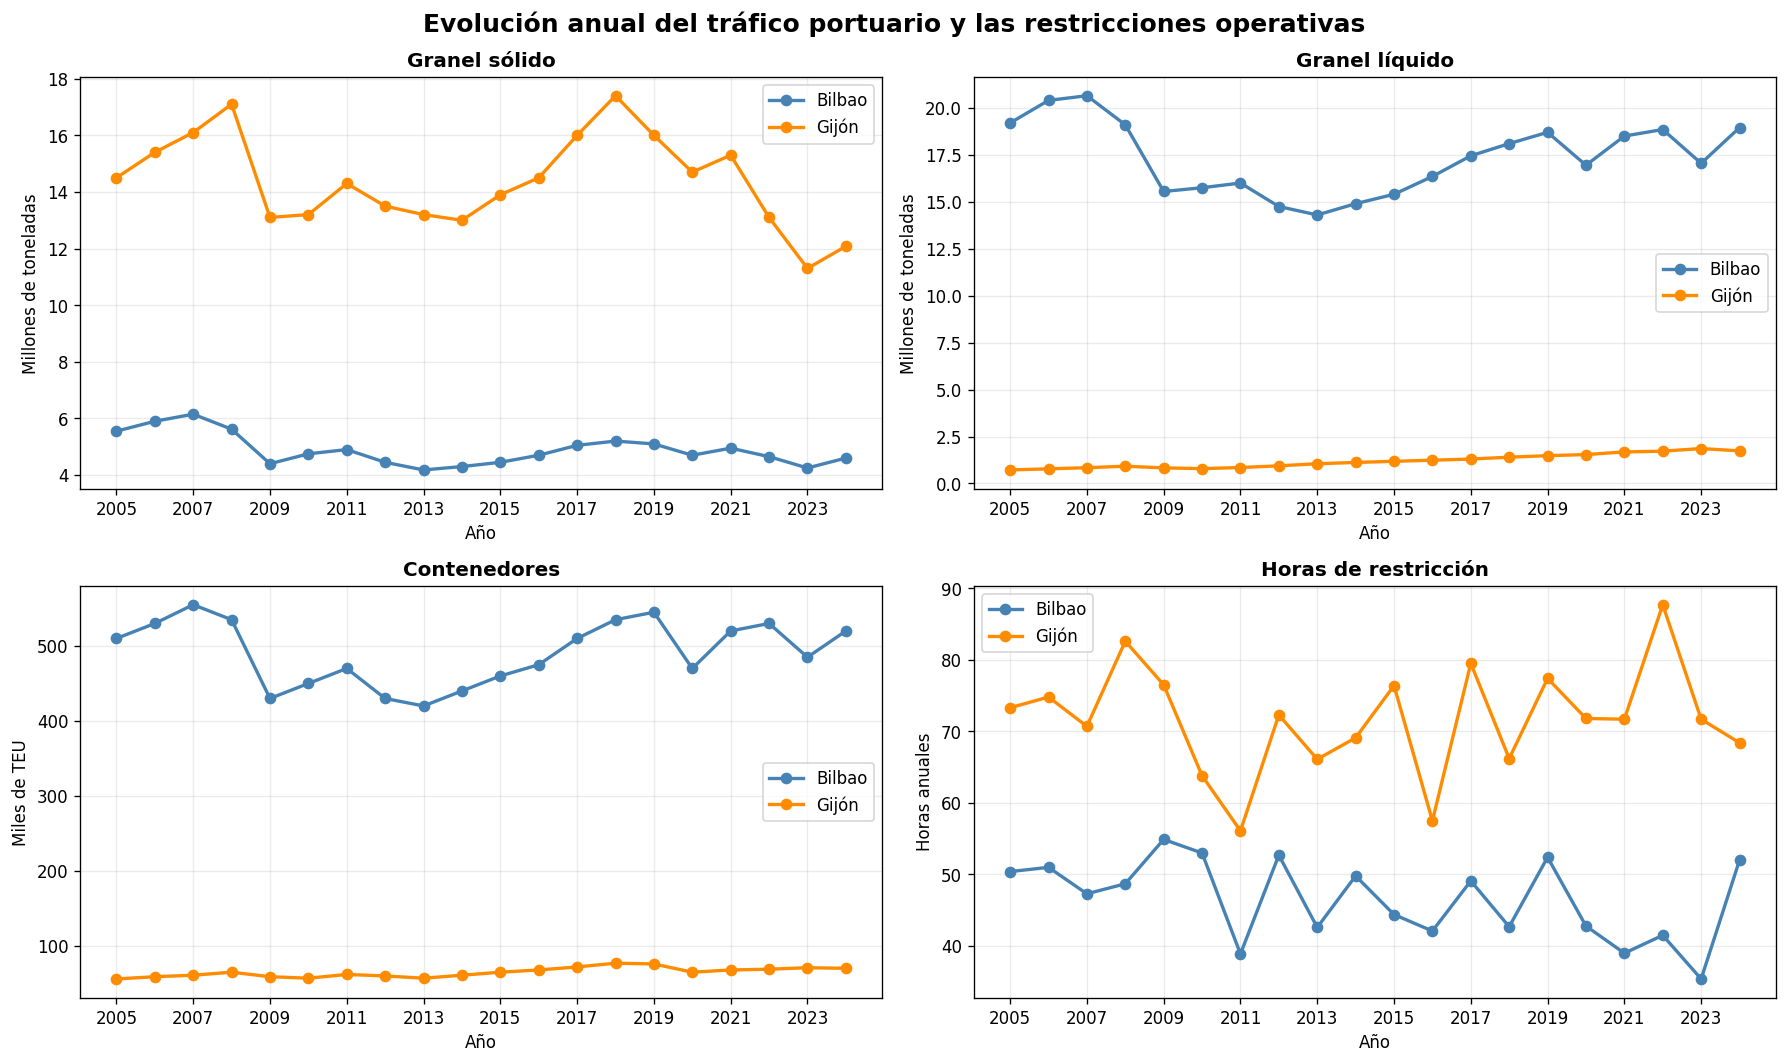

In [ ]:
# Evolución anual del tráfico y de las restricciones

variables_grafico = [
    ('granel_solido_t', 'Granel sólido', 1_000_000, 'Millones de toneladas'),
    ('granel_liquido_t', 'Granel líquido', 1_000_000, 'Millones de toneladas'),
    ('contenedores_teu', 'Contenedores', 1_000, 'Miles de TEU'),
    ('horas_restriccion', 'Horas de restricción', 1, 'Horas anuales')
]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.ravel()

colores = {'Bilbao': 'steelblue', 'Gijón': 'darkorange'}

for ax, (variable, titulo, divisor, unidad) in zip(axes, variables_grafico):

    for puerto in ['Bilbao', 'Gijón']:
        d = datos_anual[datos_anual['puerto'] == puerto]

        ax.plot(
            d['anio'],
            d[variable] / divisor,
            marker='o',
            linewidth=2,
            color=colores[puerto],
            label=puerto
        )

    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Año')
    ax.set_ylabel(unidad)
    ax.set_xticks(range(2005, 2025, 2))
    ax.grid(alpha=0.25)
    ax.legend()

fig.suptitle(
    'Evolución anual del tráfico portuario y las restricciones operativas',
    fontsize=15,
    fontweight='bold'
)

fig.tight_layout()
plt.show()